### Площадь под графиком и управление порогом

#### Цель работы

Научиться применять кривые PR и ROC для оценки моделей классификации, использовать их для выбора оптимального порога классификации

#### Содержание работы

1. Сгенерируйте датасет для бинарной классификации, обучите на нем модель логистической регрессии и постройте для этой модели кривые ROC и PR.
1. Вычислите для этой модели метрики площади под кривыми (ROC-AUC и PR-AUC).
1. Обучите на том же датасете другую модель и сравните ее эффективность по кривым и по метрикам.
1. Сгенерируйте датасет для бинарной классификации с большим дисбалансом классов, обучите на нам ту же модель и постройте кривые.
1. Используйте данные, вычисленные для построения кривых для нахождения оптимального значения порога модели. Постройте матрицу классификации для модели с порогом по умолчанию и с лучшим порогом. Сравните результаты.

#### Методические указания

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc

Начнем с получение датасета для бинарной классификации. Воспользуемся самым простым вариантом - сгенерируем его:

In [99]:
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)

Разделим выборку на обучающую и тестовую. В данном случае нам не очень важны будут показатели эффективности моделей, но важно, чтобы и тестовая и обучающая выборки имели достаточное количество точек. Поэтому поделим датасет пополам, хотя на практике такая пропорция не используется:

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)

Создадим и обучим на обучающей выборке простую модель логистической регрессии::

In [101]:
model = LogisticRegression().fit(X_train, y_train)

Логистическая регрессия, наряду со многими другими моделями классификации может работать как точечный предиктор (то есть выдавать для входного объекта наиболее вероятный класс), а может - как вероятностный (то есть для данного объекта выдавать оценки вероятности принадлежности к каждому классу, который присутствует в обучающей выборке). Сейчас мы поработаем как раз с этими вероятностями. Получить их очень легко, воспользуемся специальным методом:

In [102]:
y_pred_proba = model.predict_proba(X_test)

Мы получили матрицу вероятностей

В этой матрице количество строк совпадает с количеством объектов, которые мы передали методу (в данном случае мы передали всю тестовую выборку). Для каждого объекта в матрице указано два значения - вероятности его отнесения, по мнению модели, соответственно, к отрицательному и положительному классу. Так как задача у нас бинарная, можно заметить, что эти два числа всегда дают в сумме единицу. В общем случае, для множественной классификации, это не обязательно выполняется. Но в даннос случае нам дальше вообще понадобится только второй столбец этой матрицы.

Для построения кривой ROC используем встроенную в sklearn функцию roc_curve, которая находится в пакете metrics:

In [103]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])

Данная функция возвражает три массива: значения метрики FPR (false positive rate), TPR (true positive rate) и значение порога. Фактически, данная функция берет определенное количество значений порога (в промежутке от 0 до 1), применяет данный порог для точной классификации, исходя из переданной ей матрицы вероятностей, и вычисляет при данном значении порога две упомянутые метрики.

Значения порога нас пока не очень интересуют, а первые два массива мы используем для построения графика - того самомго ROC:

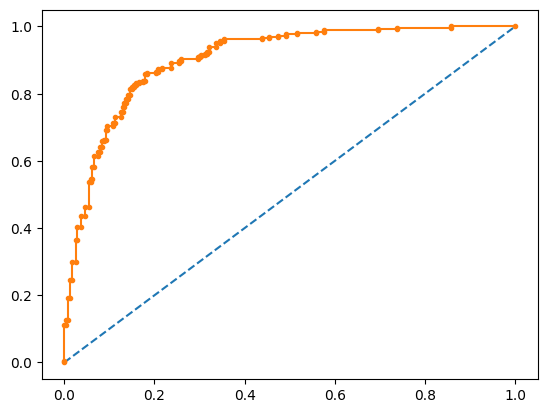

In [104]:
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.show()

Здесь мы значала рисуем прямую между точками (0,0) и (1, 1) - это референсная линия, которая представляет условный тривиальный классификатор. Именно с ней мы будем сравнивать получившуюся кривую, А она должна распологаться примено так

Из графика мы видим, что кривая находится выше прямой, что свидетельствует о том, что классификатор работает лучше, чем случайное предсказание. Но можно заметить, что при разных значениях порога (зеленые точки на графике) модель имеет значительно различающиеся характеристики. И только одна точка на этом графике характеризует поведение модели при "дефолтном" значении порога - то, что мы обычно не задумываясь получаем методом predict.

Но анализ графика может нам дать только примерное представление о том, насколько хороша модель. Особенно сейчас, когда нам не с чем ее сравнить. Боле четкую оценку даст метрика ROC-AUC, измеряющая площадь под графиком данной кривой. Эту метрику также легко получить:

In [105]:
roc_auc_score(y_test, y_pred_proba[:, 1])

0.9027724358974359

В данном случае, мы имеем значение примерно в 90,3%, что можно интерпретировать как общее качество модели вне зависимости от выбранного порога.

Давайте по аналогии построим график PR-кривой. Из лекции мы знаем, что он строится по аналогичному признаку, но в других координатах. Конечно, библиотека sklearn и здесь позволяет пользоваться готовыми функциями:

In [106]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])

Обратите внимание, что в этих координатах (precision и recall) эффективность тривиального классификатора уже не так примитивна и ависит от соотношения классов в обучающей выборке. Мы уже говорили об этом на лекции. Вот как просто можно его изобразить:

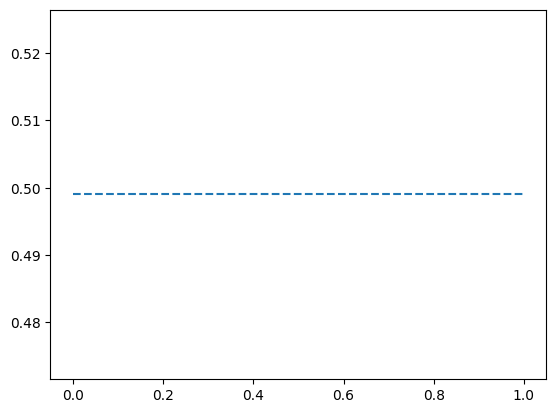

In [107]:
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')

А теперь можно вывести на график и саму кривую PR:

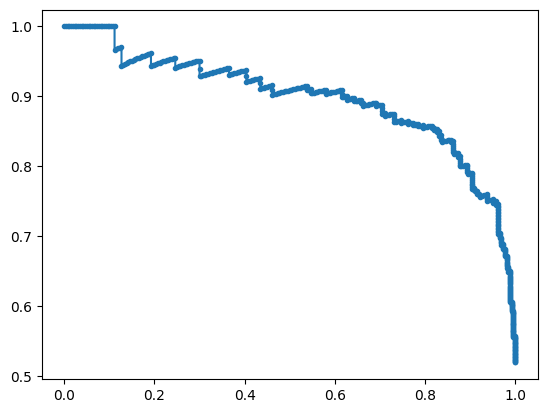

In [108]:
plt.plot(recall, precision, marker='.')
plt.show()

Точно также, как и с ROC можно вычислить соответствующую численную метрику - площадь под графиком PR-кривой - PR-AUC:

In [109]:
auc(recall, precision)

0.897662372903334

Эта метрика численно чуть ниже - порядка 89,8%. Еще это число называют средней точностью модели - average precision.

Полезно посмотреть, как полученные данные соотносятся с уже знакомыми нам характеристиками классификации. Давайте построим отчет о классификации по данной модели:

In [110]:
from sklearn.metrics import classification_report
y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.83      0.82      0.83       240
           1       0.84      0.85      0.84       260

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



Важно понимать, что данный отчет характеризует поведение модели только в одной точке - при значении порога, равном по умолчанию 0,5. Кривые же показывают, как модель будет работать при все возможных значениях порога.

Давайте для сравнения попробуем обучить на этих же данных другую модель. Например, метод ближайших сосдей. Вы можете выбрать любую другую модель (но обратите внимание, что не все модели имеют метод redict_proba, а нам он обязательно понадоится. Почему так, читайте в документации к моделям)

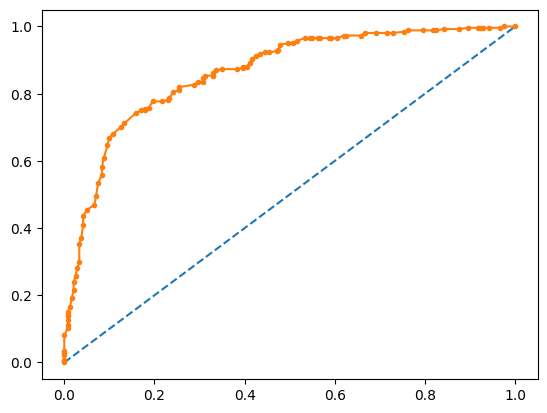

In [111]:
from sklearn.neighbors import KNeighborsClassifier

model2 = KNeighborsClassifier(n_neighbors=250).fit(X_train, y_train)
y_pred2_proba = model2.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_pred2_proba[:, 1])

plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.show()

График будет выглядеть чуть по-другому, но в целом похоже на ROC первой модели. Поэтому для точного сравнения более полезны численные метрики:

In [112]:
roc_auc_score(y_test, y_pred2_proba[:, 1])

0.8630608974358974

Тут явно видно, что ROC-AUC второй модели значимо хуже - 86,3%.

Дизбаланс классов
Наиболее явно различия между этими двумя классификационными кривыми - ROC и PR - демонстрирует пример с большим дизбалансом классов. Давайте сгенерируем датасет, в котором объектов разных классов не примерно равное количество, как в предыдущем примере, а объектов отрицательного класса, скажем, 99%. Для этого очень удобно воспользоваться атрибутом weights функции make_classification:

In [113]:
X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.99, 0.01], random_state=1)

Также разделим эту выборку на две части. Но сдесь надо быть аккуратными, поэтому сразу выведем объем классов в получившихся частях:

In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=4)

print('Датасет: Class0=%d, Class1=%d' % (len(y[y==0]), len(y[y==1])))
print('Обучающая: Class0=%d, Class1=%d' % (len(y_train[y_train==0]), len(y_train[y_train==1])))
print('Тестовая: Class0=%d, Class1=%d' % (len(y_test[y_test==0]), len(y_test[y_test==1])))

Датасет: Class0=985, Class1=15
Обучающая: Class0=490, Class1=10
Тестовая: Class0=495, Class1=5


Видно, что в одной половине выборки положительных объектов в два раза больше, чем в другой. Прислучайном разделении, если есть сильно миноритарные классы, может случиться и не такое. Например, мы можем случайно получить выборку, в которой какие-то классы не представлены вообще. Для предотвращения таких случаев нужно воспользоваться стратификацией:

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

Это агрумент следит за тем, чтобы в обоих частях выборки распределение переданного атрибута было примерно такое же, как и целом датасете. Вот какая картина получается сейчас

Распределение уже гораздо более равномерное. Для стратификации можно задавать любой массив, не обязательно значение целевой переменной, и разделение произойдет так, чтобы созранить распределение, заданное в этом массиве. Но целевую переменную здесь используют чаще всего.

Точно также, как и в предыдущем примере, обучим модель и сразу вычислим матрицу вероятностей:

In [116]:
model = LogisticRegression().fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)

Сразу познакомимся с дефолтным поведением модели, построив отчет о классификации:

In [117]:
y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       492
           1       0.00      0.00      0.00         8

    accuracy                           0.98       500
   macro avg       0.49      0.50      0.50       500
weighted avg       0.97      0.98      0.98       500



/home/kai/ML_course/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/kai/ML_course/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/kai/ML_course/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

Здесь мы видим классическую картину обучения на неравномерной выборке. Мажоритарный класс (в данном случае - отрицательный, он у нас в большинстве) распознается очень хорошо, а миноритарный - очень плохо. В нашем случае, вообще по положительному классу все метрики нулевые. Но обратите внимание, что общая точность (accuracy) модели весьма приемлема - 98%. Дизбаланс классов "скрывает" в точности недостатки работы модели.

Построим ROC данной модели:

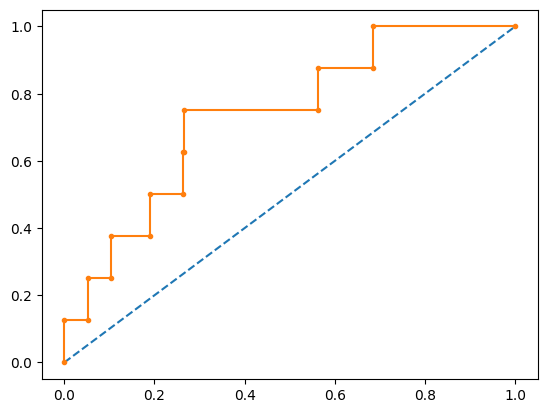

In [118]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])

plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.show()

Мы видим. что вривая показывает не идеальное, но вполне примелемое поведение модели. Средняя точность будет, несомненно, ниже, чем в первом примере работы, но ничего катастрофического мы здесь не наблюдаем. Но давайте построим кривую PR:

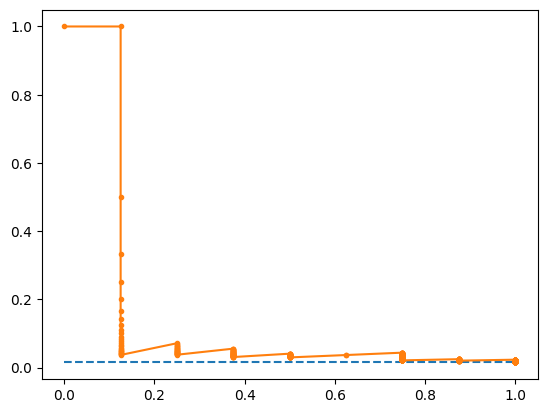

In [119]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(recall, precision, marker='.')
plt.show()

##### Выбор значения порога по кривым

Кривые классификации, несомненно, удобный и визуальный способ представления эффективности работы моделей машинного обучения. Но главная их ценность состоит в том, что данные, которые необходимы для их построения могут использоваться для оптимизации порога классификации. Мы уже поняли, что разные значения порога могут приводить к разному поведению моделей и, как следствие, к имзенению метрик. Значит, можно выбрать такой порог, который дает более точную классификацию?

Да, но для этого нам понадобится некоторый критерий - численное значение, которые мы хотим оптимизировать. В лекции мы уже говорили, что простые метрики - precision, recall, accuracy - не очень подходят на роль критерия оптимизации. Но мы можем использовать, например, метрику F1 (и любые метрики из F-семейства). Для этого еще раз сгенерируем датасет, сделаем чуть больше объем данных:

In [120]:
X, y = make_classification(n_samples=10000, n_classes=2, weights=[0.99, 0.01], random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

model = LogisticRegression().fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)

Изобразим PR-кривую:

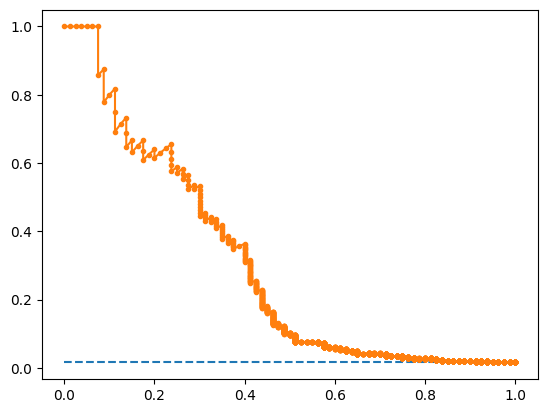

In [121]:
p, r, pr_thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.show()

По точкам на ней мы видим, что при разных значениях порога иногда метрика precision будет больше, иногда - recall. Именно поэтому мы будем оптимизировать по метрике F1. Для этого импортируем из бибилиотеки numpy функцию argmax:

In [122]:
from numpy import argmax

Вычислим вектор метрик F1 при всех использованных значениях порога и найдем самое большое значение среди них (вернее, его индекс):

In [123]:
f1 = (2 * p * r) / (p + r)
ix = argmax(f1)
pr_thresholds[ix]

np.float64(0.19294071843351387)

Так как индексы всех массивов, возвращенных функцией precision_recall_curve соответственны, по этому индексу получим значение порога и соответствующее ему значение метрики F1:

In [124]:
print('Порог=%f, F-Score=%.3f' % (pr_thresholds[ix], f1[ix]))

Порог=0.192941, F-Score=0.384


Теперь мы можем изобразить эту точку на графике самой кривой:

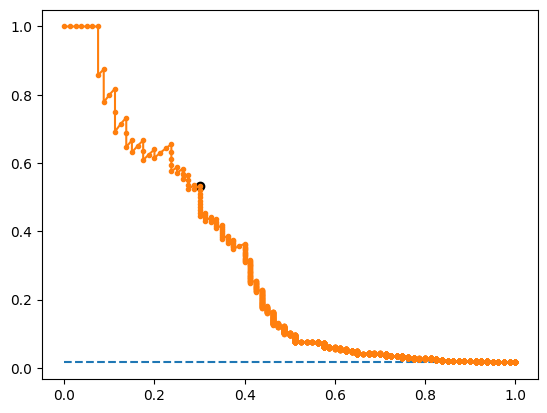

In [125]:
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.scatter(r[ix], p[ix], marker='o', color='black')
plt.show()

Обратите внимание, что мы использовали метрику F1 - это среднее геометрическое между Precision и Recall. При этом эти две метрики имеют равный вклад в среднее. Бывают ситуации, когда нам более приоритетна одна из этих двух метрик. Тогда следует использоваться параметрическую метрику из F-семейства. Мы можем придать в среднем разный вес, то есть больше предпочесть recall или, наоборот, precision.

Давайте используем данное значение порога для проведение непосредственной классификации. Раньше мы так не делали, так как всегда использовали метод predict, который всегда использует порог по умолчанию - 0,5. Но точечная классификация - это не что иное, как выбор положительного класса, если модель оценивает вероятность принадлежности к нему выше порога:

In [126]:
y_pred = (y_pred_proba[:, 1] > pr_thresholds[ix]).astype('int')

Полученный вектор значений можно использовать при построении точета о классфикации:

In [127]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4920
           1       0.52      0.29      0.37        80

    accuracy                           0.98      5000
   macro avg       0.76      0.64      0.68      5000
weighted avg       0.98      0.98      0.98      5000



А вот для сравнения, отчет о классификации для той же модели, но при использованиии порога по умолчанию:

In [128]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4920
           1       0.80      0.10      0.18        80

    accuracy                           0.99      5000
   macro avg       0.89      0.55      0.59      5000
weighted avg       0.98      0.99      0.98      5000



Самостоятельно проведите сравнение и сделайте вывод об эффективности моделей.

Порог по умолчанию 0.5 даёт очень высокую точность предсказания положительного класса 93 процента, но крайне низкую полноту всего 16 процентов. Это означает, что модель почти никогда не предсказывает положительный класс, но когда предсказывает, то в большинстве случаев правильно. Такое поведение характерно для несбалансированных данных, где положительных примеров очень мало, и модель перестраховывается, чтобы не делать ложных срабатываний. Оптимальный порог около 0.22, найденный по максимуму F1-меры, снижает точность до 81 процента, но увеличивает полноту до 31 процента, что даёт рост F1 с 0.28 до 0.45. Таким образом, настройка порога позволяет найти лучший баланс между точностью и полнотой. Выбор конкретного порога зависит от приоритетов задачи: если критично не пропустить ни одного положительного случая, нужно выбирать порог с большей полнотой даже ценой точности; если важнее избежать ложных тревог, то выбирается порог с высокой точностью.

### Контрольные вопросы

**1. Какие модели можно оценивать с помощью классификационных кривых (ROC и PR) и почему именно их?**

Оценивать с помощью ROC и PR можно любые модели, которые выдают вероятности принадлежности к классам или числовые оценки уверенности, а не только жесткое решение 0 или 1. К таким моделям относятся логистическая регрессия, случайный лес, градиентный бустинг, SVM с калибровкой вероятностей, нейронные сети. Эти кривые требуют возможности изменять порог принятия решения, что невозможно для моделей, дающих только конечную метку класса.

**2. В каких случаях лучше использовать PR-кривую, а в каких — ROC и почему?**

ROC-кривую лучше использовать при относительно сбалансированных классах, так как она показывает общую способность модели разделять классы независимо от доли положительных примеров. PR-кривая предпочтительнее при сильном дисбалансе классов, поскольку метрики precision и recall более информативны для миноритарного класса. В условиях дисбаланса ROC может создавать иллюзию хорошей работы модели, так как FPR остаётся низким просто из-за большого количества истинно отрицательных примеров, в то время как PR-кривая наглядно демонстрирует реальную эффективность модели по нахождению редкого класса.

**3. Какие виды усреднения вы знаете (micro, macro) и в чем особенности их применения?**

Macro-усреднение сначала вычисляет метрику для каждого класса отдельно, а затем усредняет результаты, придавая всем классам равный вес независимо от их размера. Оно полезно, когда важна производительность по каждому классу в отдельности. Micro-усреднение суммирует TP, FP и FN по всем классам и затем вычисляет метрику, что даёт больший вес классам с большим количеством примеров. Оно подходит, когда важна общая производительность на всех объектах.

**4. Как вычисляются метрики для построения кривых в задачах множественной классификации?**

Для множественной классификации используется подход «один против всех» (one-vs-rest). Для каждого класса строится отдельная бинарная кривая ROC или PR, где текущий класс считается положительным, а все остальные — отрицательными. Затем полученные кривые можно усреднять (micro или macro). Это позволяет оценить, насколько хорошо модель различает каждый класс на фоне всех остальных.

**5. Почему при построении кривых с помощью yellowbrick на графике отображаются сразу несколько кривых и что они значат?**

Yellowbrick отображает несколько кривых для задач множественной классификации: отдельную кривую для каждого класса (в режиме one-vs-rest), а также micro- и macro-усреднённые кривые. Это позволяет увидеть, на каких классах модель работает хорошо, а на каких плохо, и оценить обобщённую производительность. Каждая кривая характеризует способность модели отличать один конкретный класс от всех остальных.

**6. Сравните эффективность модели при пороге по умолчанию (0.5) и при оптимальном пороге, найденном по максимуму F1-меры.**

При пороге по умолчанию 0.5 модель показывает очень высокую точность (precision) для положительного класса (93%), но крайне низкую полноту (recall) — всего 16%. Это означает, что модель почти никогда не предсказывает положительный класс, но когда предсказывает, то в большинстве случаев правильно. Оптимальный порог (около 0.22), найденный по максимуму F1-меры, снижает точность до 81%, но увеличивает полноту до 31%, что повышает F1-меру с 0.28 до 0.45. Настройка порога позволяет найти лучший баланс между точностью и полнотой. Выбор конкретного порога зависит от приоритетов задачи: если критично не пропустить ни одного положительного случая (например, при диагностике опасного заболевания), предпочтителен порог с большей полнотой; если важнее избежать ложных тревог (например, в спам-фильтре), лучше порог с высокой точностью.